In [3]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from utils import load_tweets, process_tweet

%matplotlib inline

In [5]:
# Load positive and negative tweets
all_positive_tweets, all_negative_tweets = load_tweets()

# View the total number of positive and negative tweets.
print(f"The number of positive tweets: {len(all_positive_tweets)}")
print(f"The number of negative tweets: {len(all_negative_tweets)}")

The number of positive tweets: 5000
The number of negative tweets: 5000


In [6]:
# Change the tweet number to any number between 0 and 4999 to see a different pair of tweets.
tweet_number = 4
print('Positive tweet example:')
print(all_positive_tweets[tweet_number])
print('\nNegative tweet example:')
print(all_negative_tweets[tweet_number])

Positive tweet example:
yeaaaah yippppy!!!  my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days

Negative tweet example:
Dang starting next week I have "work" :(


In [7]:
# Process all the tweets: tokenize the string, remove tickers, handles, punctuation and stopwords, stem the words
all_positive_tweets_processed = [process_tweet(tweet) for tweet in all_positive_tweets]
all_negative_tweets_processed = [process_tweet(tweet) for tweet in all_negative_tweets]

In [8]:
# Change the tweet number to any number between 0 and 4999 to see a different pair of tweets.
tweet_number = 4
print('Positive processed tweet example:')
print(all_positive_tweets_processed[tweet_number])
print('\nNegative processed tweet example:')
print(all_negative_tweets_processed[tweet_number])

Positive processed tweet example:
['yeaaah', 'yipppi', 'accnt', 'verifi', 'rqst', 'succeed', 'got', 'blue', 'tick', 'mark', 'fb', 'profil', ':)', '15', 'day']

Negative processed tweet example:
['dang', 'start', 'next', 'week', 'work', ':(']


In [9]:
# Split positive set into validation and training
val_pos = all_positive_tweets_processed[4000:]
train_pos = all_positive_tweets_processed[:4000]
# Split negative set into validation and training
val_neg = all_negative_tweets_processed[4000:]
train_neg = all_negative_tweets_processed[:4000]

train_x = train_pos + train_neg 
val_x  = val_pos + val_neg

# Set the labels for the training and validation set (1 for positive, 0 for negative)
train_y = [[1] for _ in train_pos] + [[0] for _ in train_neg]
val_y  = [[1] for _ in val_pos] + [[0] for _ in val_neg]

print(f"There are {len(train_x)} sentences for training.")
print(f"There are {len(train_y)} labels for training.\n")
print(f"There are {len(val_x)} sentences for validation.")
print(f"There are {len(val_y)} labels for validation.")

There are 8000 sentences for training.
There are 8000 labels for training.

There are 2000 sentences for validation.
There are 2000 labels for validation.


In [10]:
# GRADED FUNCTION: build_vocabulary
def build_vocabulary(corpus):
    '''Function that builds a vocabulary from the given corpus
    Input: 
        - corpus (list): the corpus
    Output:
        - vocab (dict): Dictionary of all the words in the corpus.
                The keys are the words and the values are integers.
    '''

    # The vocabulary includes special tokens like padding token and token for unknown words
    # Keys are words and values are distinct integers (increasing by one from 0)
    vocab = {'': 0, '[UNK]': 1} 

    ### START CODE HERE ###
    
    # For each tweet in the training set
    for twt in corpus:
        # For each word in the tweet
        for sub_twt in twt:
            # If the word is not in vocabulary yet, add it to vocabulary
            if sub_twt not in vocab:
                vocab[sub_twt] = len(vocab)
    
    ### END CODE HERE ###
    
    return vocab


vocab = build_vocabulary(train_x)
num_words = len(vocab)

print(f"Vocabulary contains {num_words} words\n")
print(vocab)

Vocabulary contains 9144 words

{'': 0, '[UNK]': 1, 'followfriday': 2, 'top': 3, 'engag': 4, 'member': 5, 'commun': 6, 'week': 7, ':)': 8, 'hey': 9, 'jame': 10, 'odd': 11, ':/': 12, 'pleas': 13, 'call': 14, 'contact': 15, 'centr': 16, '02392441234': 17, 'abl': 18, 'assist': 19, 'mani': 20, 'thank': 21, 'listen': 22, 'last': 23, 'night': 24, 'bleed': 25, 'amaz': 26, 'track': 27, 'scotland': 28, 'congrat': 29, 'yeaaah': 30, 'yipppi': 31, 'accnt': 32, 'verifi': 33, 'rqst': 34, 'succeed': 35, 'got': 36, 'blue': 37, 'tick': 38, 'mark': 39, 'fb': 40, 'profil': 41, '15': 42, 'day': 43, 'one': 44, 'irresist': 45, 'flipkartfashionfriday': 46, 'like': 47, 'keep': 48, 'love': 49, 'custom': 50, 'wait': 51, 'long': 52, 'hope': 53, 'enjoy': 54, 'happi': 55, 'friday': 56, 'lwwf': 57, 'second': 58, 'thought': 59, '’': 60, 'enough': 61, 'time': 62, 'dd': 63, 'new': 64, 'short': 65, 'enter': 66, 'system': 67, 'sheep': 68, 'must': 69, 'buy': 70, 'jgh': 71, 'go': 72, 'bayan': 73, ':d': 74, 'bye': 75, 'act

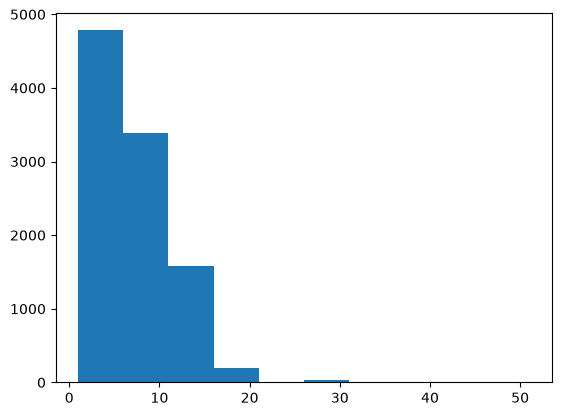

In [11]:
# Tweet lengths
plt.hist([len(t) for t in train_x + val_x]);

In [12]:
# GRADED FUNCTION: max_length
def max_length(training_x, validation_x):

    max_len = 0
    data = training_x + validation_x
    for i in range(len(data)) :
        if len(data[i]) > max_len :
            max_len = len(data[i])
    
    return max_len

max_len = max_length(train_x, val_x)
print(f'The length of the longest tweet is {max_len} tokens.')

The length of the longest tweet is 51 tokens.


In [13]:
def padded_sequence(tweet, vocab_dict, max_len, unk_token='[UNK]'):
    
    # Find the ID of the UNK token, to use it when you encounter a new word
    unk_ID = vocab_dict[unk_token] 
    lst =[]
    # First convert the words to integers by looking up the vocab_dict
    for wrd in tweet:
        lst.append(vocab_dict.get(wrd, unk_ID))
        
    # Then pad the tensor with zeroes up to the length max_len
    padded_tensor = lst + [0]* (max_len - len(lst))

    return padded_tensor

In [14]:
train_x_padded = [padded_sequence(x, vocab, max_len) for x in train_x]
val_x_padded = [padded_sequence(x, vocab, max_len) for x in val_x]

In [15]:
def relu(x):
    '''Relu activation function implementation
    Input: 
        - x (numpy array)
    Output:
        - activation (numpy array): input with negative values set to zero
    '''
    ### START CODE HERE ###

    activation = np.maximum(0,x)

    ### END CODE HERE ###

    return activation

In [16]:
# Check the output of your function
x = np.array([[-2.0, -1.0, 0.0], [0.0, 1.0, 2.0]], dtype=float)
print("Test data is:")
print(x)
print("\nOutput of relu is:")
print(relu(x))

Test data is:
[[-2. -1.  0.]
 [ 0.  1.  2.]]

Output of relu is:
[[0. 0. 0.]
 [0. 1. 2.]]


In [17]:
# GRADED FUNCTION: sigmoid
def sigmoid(x):
    '''Sigmoid activation function implementation
    Input: 
        - x (numpy array)
    Output:
        - activation (numpy array)
    '''
    ### START CODE HERE ###

    activation = 1/(1+np.exp(-x))

    ### END CODE HERE ###

    return activation    

In [18]:
# Check the output of your function
x = np.array([[-1000.0, -1.0, 0.0], [0.0, 1.0, 1000.0]], dtype=float)
print("Test data is:")
print(x)
print("\nOutput of sigmoid is:")
print(sigmoid(x))

Test data is:
[[-1000.    -1.     0.]
 [    0.     1.  1000.]]

Output of sigmoid is:
[[0.         0.26894142 0.5       ]
 [0.5        0.73105858 1.        ]]


C:\Users\EQUIPO\AppData\Local\Temp\ipykernel_20356\1646423196.py:11: RuntimeWarning: overflow encountered in exp
  activation = 1/(1+np.exp(-x))


In [19]:
# GRADED CLASS: Dense
class Dense():
    """
    A dense (fully-connected) layer.
    """

    # Please implement '__init__'
    def __init__(self, n_units, input_shape, activation, stdev=0.1, random_seed=42):
        
        # Set the number of units in this layer
        self.n_units = n_units
        # Set the random key for initializing weights
        self.random_generator = np.random.default_rng(seed=random_seed)
        self.activation = activation
        
        ### START CODE HERE ###

        # Generate the weight matrix from a normal distribution and standard deviation of 'stdev'
        # Set the size of the matrix w
        w = self.random_generator.normal(scale=stdev, size = (input_shape[-1] if isinstance(input_shape, (tuple, list)) else input_shape, self.n_units))
        
        ### END CODE HERE ##

        self.weights = w
        

    def __call__(self, x):
        return self.forward(x)
    
    
    # Please implement 'forward()'
    def forward(self, x):
        
        ### START CODE HERE ###

        # Matrix multiply x and the weight matrix
        dense = np.dot(x, self.weights)
        # Apply the activation function
        dense = self.activation(dense)
        
        ### END CODE HERE ###
        return dense

In [20]:
# random_key = np.random.get_prng()  # sets random seed
z = np.array([[2.0, 7.0, 25.0]]) # input array

# Testing your Dense layer 
dense_layer = Dense(n_units=10, input_shape=z.shape, activation=relu)  #sets  number of units in dense layer

print("Weights are:\n",dense_layer.weights) #Returns randomly generated weights
print("Foward function output is:", dense_layer(z)) # Returns multiplied values of units and weights

Weights are:
 [[ 0.03047171 -0.10399841  0.07504512  0.09405647 -0.19510352 -0.13021795
   0.01278404 -0.03162426 -0.00168012 -0.08530439]
 [ 0.0879398   0.07777919  0.00660307  0.11272412  0.04675093 -0.08592925
   0.03687508 -0.09588826  0.08784503 -0.00499259]
 [-0.01848624 -0.06809295  0.12225413 -0.01545295 -0.04283278 -0.03521336
   0.05323092  0.03654441  0.04127326  0.0430821 ]]
Foward function output is: [[0.21436609 0.         3.25266507 0.59085808 0.         0.
  1.61446659 0.17914382 1.64338651 0.87149558]]


In [21]:
def create_model(num_words, embedding_dim, max_len):
    """
    Creates a text classifier model
    
    Args:
        num_words (int): size of the vocabulary for the Embedding layer input
        embedding_dim (int): dimensionality of the Embedding layer output
        max_len (int): length of the input sequences
    
    Returns:
        model (tf.keras Model): the text classifier model
    """
    
    tf.random.set_seed(123)
    
    ### START CODE HERE
    
    model = tf.keras.Sequential([ 
        tf.keras.layers.Embedding(num_words, embedding_dim, input_length=max_len),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(units= 1, activation ="sigmoid")
    ]) 
    
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

    ### END CODE HERE

    return model

In [22]:
# Create the model
model = create_model(num_words=num_words, embedding_dim=16, max_len=max_len)

print('The model is created!\n')

C:\Users\EQUIPO\desktop\projects\nlp sentiment analysis\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


The model is created!



In [23]:
# Prepare the data
train_x_prepared = np.array(train_x_padded)
val_x_prepared = np.array(val_x_padded)

train_y_prepared = np.array(train_y)
val_y_prepared = np.array(val_y)

print('The data is prepared for training!\n')

# Fit the model
print('Training:')
history = model.fit(train_x_prepared, train_y_prepared, epochs=20, validation_data=(val_x_prepared, val_y_prepared))

The data is prepared for training!

Training:
Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6779 - loss: 0.6588 - val_accuracy: 0.9655 - val_loss: 0.6076
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9572 - loss: 0.5198 - val_accuracy: 0.9965 - val_loss: 0.4360
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9934 - loss: 0.3438 - val_accuracy: 0.9970 - val_loss: 0.2798
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9964 - loss: 0.2150 - val_accuracy: 0.9970 - val_loss: 0.1806
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9971 - loss: 0.1390 - val_accuracy: 0.9960 - val_loss: 0.1229
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9971 - loss: 0.0953 - val_accuracy: 0.9960 - val_loss: 0.0883
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9976 - loss: 0.0689 - val_accuracy: 0.9960 - val_loss: 0.0664
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accu

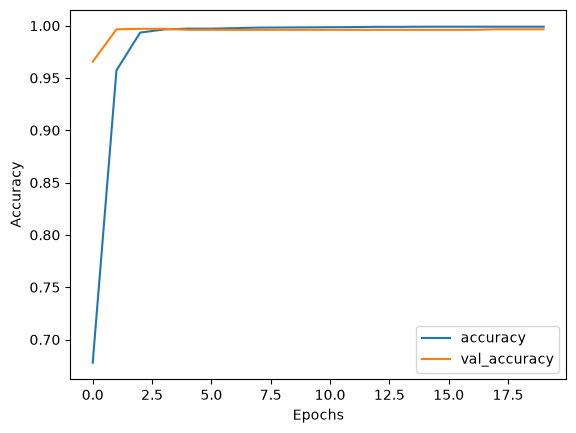

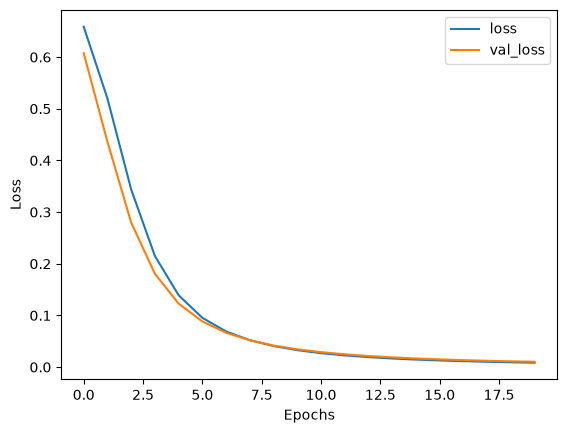

In [24]:
def plot_metrics(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history[f'val_{metric}'])
    plt.xlabel("Epochs")
    plt.ylabel(metric.title())
    plt.legend([metric, f'val_{metric}'])
    plt.show()
    
plot_metrics(history, "accuracy")
plot_metrics(history, "loss")

In [25]:
# Prepare an example with 10 positive and 10 negative tweets.
example_for_prediction = np.append(val_x_prepared[0:10], val_x_prepared[-10:], axis=0)

# Make a prediction on the tweets.
model.predict(example_for_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


array([[9.9615395e-01],
       [9.9936277e-01],
       [9.9692363e-01],
       [9.9200326e-01],
       [9.9730325e-01],
       [9.9811888e-01],
       [9.9003637e-01],
       [9.8595291e-01],
       [9.9885488e-01],
       [9.9942988e-01],
       [1.0496925e-03],
       [3.0322499e-03],
       [1.1093662e-03],
       [1.4011960e-03],
       [1.6683745e-03],
       [8.3338108e-04],
       [1.0652812e-03],
       [1.1192445e-03],
       [1.4392110e-03],
       [1.8800642e-02]], dtype=float32)

In [26]:
def get_prediction_from_tweet(tweet, model, vocab, max_len):
    tweet = process_tweet(tweet)
    tweet = padded_sequence(tweet, vocab, max_len)
    tweet = np.array([tweet])

    prediction = model.predict(tweet, verbose=False)
    
    return prediction[0][0]

In [27]:
unseen_tweet = '@DLAI @NLP_team_dlai OMG!!! what a daaay, wow, wow. This AsSiGnMeNt was great.'
def neural_nets_prediction(text):
    print(process_tweet(text))
    prediction_unseen = get_prediction_from_tweet(text, model, vocab, max_len)
    print(prediction_unseen)
    if prediction_unseen > 0.5:
        print('Positive sentiment')
    elif prediction_unseen == 0 :
        print ('neutrale sentiment')
    else: 
        print('Negative sentiment')
neural_nets_prediction(unseen_tweet)

['omg', 'daaay', 'wow', 'wow', 'assign', 'great']
0.79189235
Positive sentiment
